### Importação das Bibliotecas

In [18]:
import numpy as np
import matplotlib.pyplot as plt

### Carregamento dos Dados com CSV

In [19]:
# try: 
#     # Delimitador é vírgula e pula a primeira linha (cabeçalho) com skiprows
#     # dados = np.loadtxt('.csv', delimiter=',', skiprows=1, usecols=(2, 3)) 
# except FileNotFoundError:
#     print("Erro: arquivo 'dataset.csv' não encontrado")
#     print("Por favor, crie o arquivo ou execute o script para gerá-lo.")
#     exit()

In [20]:
# apenas visualiza os dados carregados do arquivo CSV
# print(dados)

### Separando os dados e X e Y

In [21]:
# criando dados (já que não há dataset para usar como base)
# X = variável independente (anos de experiência)
# Y = variável dependente a ser prevista (salário em R$)
x = np.array([10, 5, 6, 9, 2]) # anos de experiência
y = np.array([8500, 3000, 7000, 7250, 1630]) # salário

# Visualiza os dados
print('Anos de experiência (X):', x)
print('Salário (Y):', y)

print("\nNúmero de amostras: ", x.shape[0])

Anos de experiência (X): [10  5  6  9  2]
Salário (Y): [8500 3000 7000 7250 1630]

Número de amostras:  5


In [22]:
x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

print('X:', x)
print('\nY:', y)

# Descomente a linha abaixo se quiser ver detalhes dos dados

#print('Número de características:', x.reshape[1])
#print('Número de saídas)

X: [[10]
 [ 5]
 [ 6]
 [ 9]
 [ 2]]

Y: [[8500]
 [3000]
 [7000]
 [7250]
 [1630]]


### Calculando 'A' e 'B'

In [23]:
# Calcular os coeficientes da regressão linear (A e B)
x_mean = np.mean(x)
y_mean = np.mean(y)

print('Média de X:', x_mean)
print('Média de Y:', y_mean)

Média de X: 6.4
Média de Y: 5476.0


In [24]:
def predict(x_novo, _m, _b):
    """
    Prevê novos valores de y com base nos coeficientes da regressão.
    Args:
        x_novo: Um número ou array NumPy com os novos valores de x.
        m: Coeficiente angular (slope) do modelo.
        b: O intercepto do modelo
    Returns: O(s) valor(es) de y previstos
    """
    return _m * x_novo + _b

Coeficientes calculados a partir do CSV: 
Coeficiente angular (m): 856.2621
Intercepto (b) -4.0777

Equação da linha: y = 856.2621x + -4.0777

Coeficiente de Determinação (R²): 0.8500
O modelo tem um bom ajuste aos dados.


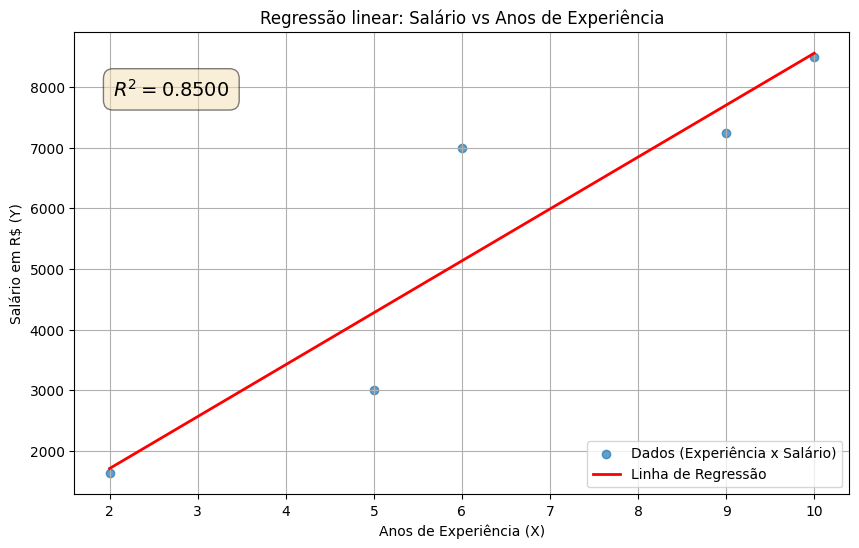

In [25]:
m = len(x)
numerador = np.sum((x - x_mean) * (y - y_mean))
denominador = np.sum((x - x_mean) ** 2)

m = numerador / denominador
b = y_mean - (m * x_mean)

# Fazer as previsões do modelo
# Para cada valor de x, calculamos o y previsto (^y) pela nossa linha.
y_pred = m * x + b

# Calcular o R-quadrado (R²) para avaliar o modelo 
sqr = np.sum((y - y_pred) ** 2) # Soma quadrática dos resíduos
sqt = np.sum((y - y_mean) ** 2) # Soma quadrática total
r2 = 1 - (sqr / sqt)

# Imprimir os resultados
print(f"Coeficientes calculados a partir do CSV: ")
print(f"Coeficiente angular (m): {m:.4f}")
print(f"Intercepto (b) {b:.4f}")
print("\nEquação da linha: y = {:.4f}x + {:.4f}".format(m, b))
print(f"\nCoeficiente de Determinação (R²): {r2:.4f}")
if r2 > 0.75:
    print('O modelo tem um bom ajuste aos dados.')
elif r2 > 0.5:
    print('O modelo tem um ajuste moderado')
else:
    print('O modelo tem um ajuste fraco')

# Criar a linha de regressão para Visualização
x_line = np.array([x.min(), x.max()])
y_line = m * x_line + b

# Visualizar os resultados
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Dados (Experiência x Salário)', alpha=0.7)
plt.plot(x_line, y_line, color='red', linewidth=2, label='Linha de Regressão')

# Adiciona o valor R² ao gráfico para fácil vizualização
plt.text(0.05, 0.9, f'$R^2 = {r2:.4f}$', transform=plt.gca().transAxes,
         fontsize=14, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

plt.title("Regressão linear: Salário vs Anos de Experiência")
plt.xlabel('Anos de Experiência (X)')
plt.ylabel('Salário em R$ (Y)')
plt.legend()
plt.grid(True)
plt.show()

a) O modelo mostra uma relação linear entre anos de experiência e salário? O gráfico sugere uma tendência clara?
- **Sim.** O gráfico sugere uma tendência linear positiva bem nítida: quanto maior o número de anos de experiência, maior tende a ser o salário do colaborador. Além disso, o coeficiente de determinação obtido foi **R² = 0,8500**, indicando que 85% da variação salarial é explicada pelos anos de experiência nesta amostra, o que representa um bom ajuste linear aos dados.

b) Qual é a interpretação do coeficiente angular nesse caso (quanto aumenta o salário a cada ano de experiência)?
- **Coeficiente angular (m): 856,2621** (ou aproximadamente R$ 856,26).
- **Interpretação:** No contexto do problema, para **cada ano adicional de experiência**, espera-se que o salário do funcionário aumente em média **R$ 856,26**.

c) Se um funcionário tiver 25 anos de experiência, qual salário seria previsto pelo modelo? Essa previsão faz sentido na prática?
- **Cálculo:** y = 856,2621 * 25 - 4,0777 ≈ **R$ 21.402,48**.
- **Análise prática:** Embora o valor nominal de R$ 21,4 mil seja plausível para cargos sêniores de liderança ou especialistas em tecnologia, trata-se de uma **extrapolação muito distante** da faixa de dados amostrada (que vai de 2 a 10 anos). Na prática, prever para 25 anos usando um modelo linear simples pode superestimar ou subestimar o ganho, pois o crescimento salarial tende a desacelerar ou atingir um teto após certo ponto na carreira.

d) Há sinais de que a progressão salarial não é perfeitamente linear (ex.: ganhos maiores após certo tempo)? Como isso poderia afetar a escolha do modelo?
- **Sim.** Observando os pontos reais, um funcionário com 5 anos ganha R$ 3.000, enquanto com 6 anos já ganha R$ 7.000 (um salto expressivo de R$ 4.000 em apenas 1 ano), e depois entre 6 e 10 anos os aumentos são mais graduais (de R$ 7.000 a R$ 8.500). Isso indica possíveis mudanças de nível de senioridade (ex.: júnior para pleno/sênior) ou promoções a cargos de gestão. Esses saltos sugerem que um modelo polinomial, uma curva logística ou uma regressão segmentada por faixas de senioridade poderiam capturar melhor a progressão salarial do que uma reta rígida.

e) Quais limitações você enxerga ao usar apenas anos de experiência como variável explicativa para o salário?
- **Limitações:** O tempo de experiência isolado não reflete todo o valor e complexidade profissional. Outros fatores decisivos incluem:
  - **Cargo e nível de senioridade:** desenvolvedor, arquiteto de software, gerente de projetos, etc.;
  - **Habilidades técnicas e certificações:** domínio de stacks demandadas pelo mercado;
  - **Formação acadêmica:** graduação, pós-graduação, especializações;
  - **Desempenho e produtividade individual;**
  - **Porte da empresa e localização geográfica.**
  Por isso, em um cenário realista de Recursos Humanos, o ideal seria adotar uma **regressão linear múltipla** contemplando essas variáveis.